## Team STAR Part 1: Get comfortable using Tsim
![surface_code.png](./assets/surface_code.png)

Familiarize yourself with the surface code and its stabilizer structure. 
Use Tsim to construct a distance-3 surface code and simulate two rounds of syndrome extraction.

Start by identifying the data and ancilla qubits, the stabilizer checks being measured, and how syndrome information is extracted over time. 
Use this part to get comfortable building the code in Tsim, running repeated syndrome cycles, and understanding how errors affect the circuit.

**Goal:** Build intuition for the distance-3 surface code, repeated syndrome extraction, and the simulation workflow in Tsim.


In [155]:
# Using Squin
from typing import Any

from bloqade import squin, tsim
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
# import tsim

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)


@squin.kernel
def bell_state() -> Measurement:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

show_circuit(bell_state)

def build_stabilizer_supports(n):
    """
    Costruisce i supporti degli stabilizzatori per una rotated surface code n x n.

    Ritorna:
        z_supports: tuple di tuple
        x_supports: tuple di tuple

    Convenzione data qubit:
        0   1   2
        3   4   5
        6   7   8
    """

    if n < 3:
        raise ValueError("n deve essere almeno 3")

    if n % 2 == 0:
        raise ValueError("n deve essere dispari: 3, 5, 7, ...")

    expected = (n**2 - 1) // 2

    def q(row, col):
        return row * n + col

    z_supports = []
    x_supports = []

    # =========================
    # Z STABILIZERS
    # =========================

    # Bordo alto: coppie orizzontali
    for col in range(0, n - 1, 2):
        z_supports.append((
            q(0, col),
            q(0, col + 1),
        ))

    # Interni Z: plaquette 2x2 con parità dispari
    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                z_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

    # Bordo basso: coppie orizzontali sfalsate
    for col in range(1, n - 1, 2):
        z_supports.append((
            q(n - 1, col),
            q(n - 1, col + 1),
        ))

    # =========================
    # X STABILIZERS
    # =========================

    for row in range(n - 1):

        # Bordo sinistro: coppie verticali sfalsate
        if row % 2 == 1:
            x_supports.append((
                q(row, 0),
                q(row + 1, 0),
            ))

        # Interni X: plaquette 2x2 con parità pari
        for col in range(n - 1):
            if (row + col) % 2 == 0:
                x_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

        # Bordo destro: coppie verticali
        if row % 2 == 0:
            x_supports.append((
                q(row, n - 1),
                q(row + 1, n - 1),
            ))

    if len(z_supports) != expected:
        raise RuntimeError(
            f"Z stabilizers generati: {len(z_supports)}, attesi: {expected}"
        )

    if len(x_supports) != expected:
        raise RuntimeError(
            f"X stabilizers generati: {len(x_supports)}, attesi: {expected}"
        )

    return tuple(z_supports), tuple(x_supports)

def surface_debug_text(n, z_supports, x_supports):
    """
    Crea una stringa debug invece di stampare direttamente.
    In Jupyter è più affidabile: puoi fare print(debug_text).
    """

    lines = []

    lines.append("\nDATA QUBITS")
    lines.append("=" * 70)

    for row in range(n):
        line = "   ".join(f"{row * n + col:02d}" for col in range(n))
        lines.append(line)

    lines.append("\nZ STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(z_supports):
        lines.append(f"z_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nX STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(x_supports):
        lines.append(f"x_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nVISUAL MAP")
    lines.append("=" * 70)
    lines.append("D = data qubit, Z = stabilizzatore Z, X = stabilizzatore X\n")

    size = 2 * n + 1
    grid = [["." for _ in range(size)] for _ in range(size)]

    # Data qubits
    for row in range(n):
        for col in range(n):
            data_idx = row * n + col
            grid[2 * row + 1][2 * col + 1] = f"D{data_idx:02d}"

    # Z stabilizers
    z_counter = 0

    for col in range(0, n - 1, 2):
        grid[0][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                grid[2 * row + 2][2 * col + 2] = f"Z{z_counter:02d}"
                z_counter += 1

    for col in range(1, n - 1, 2):
        grid[2 * n][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    # X stabilizers
    x_counter = 0

    for row in range(n - 1):

        if row % 2 == 1:
            grid[2 * row + 2][0] = f"X{x_counter:02d}"
            x_counter += 1

        for col in range(n - 1):
            if (row + col) % 2 == 0:
                grid[2 * row + 2][2 * col + 2] = f"X{x_counter:02d}"
                x_counter += 1

        if row % 2 == 0:
            grid[2 * row + 2][2 * n] = f"X{x_counter:02d}"
            x_counter += 1

    for row in grid:
        lines.append("".join(f"{cell:>6}" for cell in row))

    return "\n".join(lines)

In [ ]:
@squin.kernel
def inizialize_qubits(data: Register, ancillas: Register, n:int, num_ancillas:int, z_supports: tuple) -> Measurement
    for i in range(n**2):
        squin.reset(data[i])

    for i in range(num_ancillas):
        squin.reset(ancillas[i])

    for stab_idx in range(len(z_supports)):
        for data_idx in z_supports[stab_idx]:
            squin.cx(data[data_idx], ancillas[stab_idx])


    return squin.broadcast.measure(z_supports)



@squin.kernel                                       # must be a kernel, not plain fn
def syndrome_round(data: Register, ancillas: Register, n:int, num_x:int, num_z:int) -> Measurement:
    z_supports, x_supports = build_stabilizer_supports(n)
    num_ancillas = num_x+num_z
    for i in range(num_ancillas):
        squin.reset(ancillas[i])

def make_helpers(d, angle):
    z_supports, x_supports = build_stabilizer_supports(d)
    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    @squin.kernel  # must be a kernel, not plain fn
    def syndrome_round(data: Register, ancillas: Register) -> Measurement:
        z_supports = build_stabilizer_supports(len(data))
        num_ancillas = len(ancillas)
        for i in range(num_ancillas):
            squin.reset(ancillas[i])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        for stab_idx in range(num_z):
            for data_idx in z_supports[stab_idx]:
                squin.cx(data[data_idx], ancillas[stab_idx])

        for stab_idx in range(num_x):
            for data_idx in x_supports[stab_idx]:
                squin.cx(ancillas[num_z + stab_idx], data[data_idx])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        return squin.broadcast.measure(ancillas)

    @squin.kernel
    def physical_rotation(data:Register):
        for idx in range(0, num_data, d):
            squin.rz(angle, data[idx])
            
    @squin.kernel
    def circuit() -> Measurement:
        data     = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        m0 = inizialize_qubits(data, ancillas, n, num_ancillas, z_supports)

        m1 = syndrome_round(data, ancillas, n, num_x, num_z)
        m2 = syndrome_round(data, ancillas, n, num_x, num_z)

        for i in range(num_ancillas):
            squin.set_detector([m1[i], m2[i]], [])

        return m2

    return circuit

In [ ]:
d = 3

distance_n_surface = make_distance_n_surface_2rounds(d)

# print(debug_text)
show_circuit(distance_n_surface)

## Team STAR Part 2: Estimate STAR Fidelities
Review the STAR circuits that have been provided in the assets folder and use Tsim to simulate them in a noisy setting. 
Reproduce the fidelity plot below using data from your Tsim simulations.

![star_sim.svg](./assets/star_sim.svg)

The provided circuits are for a default rotation angle of 0.01*pi. To simulate different rotation angles, you can use the following function to compute the physical rotation angle needed to achieve a logical rotation of angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

Also make sure to check out the comments in `circuits/star_d=3.stim` to get some hints about the circuit structure.

**Goal:** Learn how to load and run pre-built circuits using Tsim. 


In [131]:
# Note: This is a STAR circuit for preparing a single logical qubit in the |+> state
# that has been rotated by 0.01*pi around the Z axis.

# The steps are:

# 1. Initialize a logical |+> state 
# 2. Perform d physical rotations
# 3. Perform two rounds of stabilizer measurement
# 4. Now post-select on perfect stabilizers
# 5. Perform d rounds of stabilizer measurement
# 6. Perform a perfect logical unrotation (this is impossible on a real quantum computer, but works in a simulation). 

# In the ideal case, this would bring us back to the logical |+> state. If we measure the logical |+>, we should obtain the result 0.
# If we get a 1, we know that a logical error has occurred. This is a simple way to check for logical errors in a simulation.

# Building in Squin
def build_star_rotation(physical_angle):
    pass


In [ ]:
# Using import from_file

import stim
import matplotlib.pyplot as plt

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)


def load_star_circuit(d: int, logical_angle_in_pi: float) -> tsim.Circuit:
    base = tsim.Circuit.from_file(f"assets/star_circuits/star_d={d}.stim")
    return base
    new_phys = physical_angle(logical_angle_in_pi, d)

    patched = stim.Circuit()
    for instr in base:
        if instr.name == "I" and instr.tag and instr.tag.startswith("R_Z("):
            targets = [t.value for t in instr.targets_copy()]
            # d targets → physical transversal rotation; 1 target → logical unrotation
            tag = (f"R_Z(theta={new_phys}*pi)" if len(targets) == d
                   else f"R_Z(theta={-logical_angle_in_pi}*pi)")
            patched.append("I", targets, tag=tag)
        else:
            patched.append(instr)

    return tsim.Circuit.from_stim_program(patched)

def dump(circuit, filename="./temp.txt"):
    with open(filename, mode="w") as f:
        for instr in circuit:
            f.write(str(instr))
            f.write("\n")

# Dump
base = tsim.Circuit.from_file(f"assets/star_circuits/star_d=3.stim")
dump(base, "base.txt")
dump(load_star_circuit(d=3, logical_angle_in_pi=0.5))


DOING 3...
Angle 0.0.
Angle 0.03183098861837907.
Angle 0.06366197723675814.
Angle 0.0954929658551372.
Angle 0.12732395447351627.
Angle 0.15915494309189535.
Angle 0.1909859317102744.
Angle 0.22281692032865347.
Angle 0.25464790894703254.
Angle 0.2864788975654116.
Angle 0.3183098861837907.
DOING 5...
Angle 0.0.
Angle 0.03183098861837907.
Angle 0.06366197723675814.
Angle 0.0954929658551372.
Angle 0.12732395447351627.
Angle 0.15915494309189535.
Angle 0.1909859317102744.
Angle 0.22281692032865347.
Angle 0.25464790894703254.
Angle 0.2864788975654116.
Angle 0.3183098861837907.


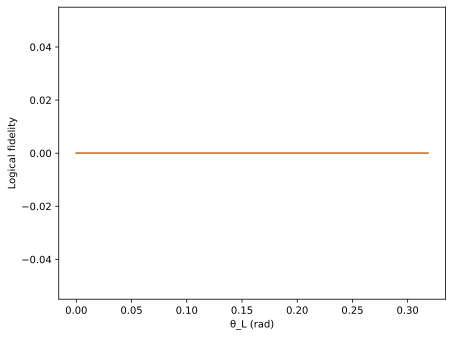

In [144]:
shots = 500
angles_pi = np.linspace(0, 1/np.pi, 11)   # logical angle in units of π
for d in [3,5]:    
    print(f"DOING {d}...")
    log_errors = []

    for angle in angles_pi:
        print(f"Angle {angle}.")
        circ = load_star_circuit(d=d, logical_angle_in_pi=angle)
        sampler = circ.compile_detector_sampler(seed=42)
        dets, obs = sampler.sample(shots, separate_observables=True)
        clean = (dets == 0).all(axis=1)
        err = obs[clean, 0].mean()
        log_errors.append(err)

    plt.plot(angles_pi, log_errors)

plt.xlabel("θ_L (rad)")
plt.ylabel("Logical fidelity")
plt.tight_layout()
plt.show()

## Team STAR Part 3 — Teleport a non-Clifford rotation into a logical qubit
Now assume a noiseless setting but where non-Clifford gates cannot be applied directly to the main logical qubit. 
Construct a protocol that uses an ancillary logical qubit to teleport a small-angle rotation into the main qubit while assuming the STAR transversal architecture.
Important: you will need to use postselection to filter results because Tsim (unlike PyQrack) does not support feed-forwarded operations.

![rus.png](./assets/rus.png)

Figure taken from *"Partially Fault-Tolerant Quantum Computing Architecture with Error-Corrected Clifford Gates and Space-Time Efficient Analog Rotations"* by *Akahoshi et al.*

**Goal:** Show how STAR enables indirect implementation of small-angle non-Clifford logical rotations, and analyze the costs of doing so. 


In [ ]:
# part 3